# First-Five-Days -- a quantitative teardown
### F5D Early Warning System * ^GSPC 1950-2025 * binomial test * HAC contrast * mechanical overlap * sub-period decay

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Beats_the_base_rate%3F: No](https://img.shields.io/badge/Beats_the_base_rate%3F-No-c0392b?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) -- *same seven beats, every claim now carrying its standard error.*  We test whether the sign of the S&P 500's return over the first five trading days of January predicts the full-year return, with a binomial test vs the coin and vs the unconditional base rate, a HAC t-stat on the mean contrast, a permutation control, and a sub-period stability check.

> **Not investment advice.**  Real data: Yahoo ^GSPC daily, 1949-present, resampled to annual F5D and full-year series, as-of 2026-06-15; fingerprint `04a2745a0f8a`.  Methods in [`docs/references.md`](../docs/references.md), reproducible numbers in [`docs/results.md`](../docs/results.md).
>
> **In plain words** notes translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from first_five_days import data, strategy as st

def _have_cache():
    return os.path.exists(data._cache_path(data.DEFAULT_CACHE)) or \
           os.path.exists(data._cache_path_daily(data.DEFAULT_CACHE))

HAVE_REAL = _have_cache()

def get_real():
    return data.fetch_gspc(fetch=False)

print("real annual cache present:", HAVE_REAL)

from quantlab import analytics, stats


real annual cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Hit-rate **69.7 %** beats coin (p = 0.0004) but **not the base rate 73.7 %** (p = 0.8200); contrast 12.9 %, HAC *t* = 4.87 full-sample, inflated by mechanical overlap; post-1985 hit-rate 60 % not sig vs coin (p = 0.134); n = 76 is tiny. |
| **Tradability** | `MIRAGE` | Strategy 8.0 %/yr vs B&H 7.9 %/yr; margin within noise at n = 76; signal fragile post-1985. |
| **Beats the base rate?** | `NO` | Hit-rate 69.7 % < base rate 73.7 % (p = 0.8200).  The almanac is not more accurate than 'equity markets drift upward'. |

> **In plain words:** the F5D indicator beats a coin but only because the coin ignores the equity premium.  Against the correct null it adds nothing, the contrast is inflated by mechanical overlap, and the effect decays post-1985.

## 1 The claim, steelmanned

Let $r^{\text{f5d}}_y$ be the log-return of the S&P 500 over the first five trading days of January in year $y$, and $r^{\text{year}}_y$ the full-year log-return (December to December).  The First-Five-Days claim asserts:

- **H1 (directional).** $P(r^{\text{year}}_y > 0 \mid \text{sign}(r^{\text{f5d}}_y) = +1) > P(r^{\text{year}}_y > 0)$ -- the conditional hit-rate exceeds the unconditional base rate.
- **H2 (magnitude).** $\mathbb{E}[r^{\text{year}}_y \mid \text{sign}(r^{\text{f5d}}_y) = +1] > \mathbb{E}[r^{\text{year}}_y \mid \text{sign}(r^{\text{f5d}}_y) = -1]$ -- the return contrast is real and stable.
- **H3 (tradable).** Long after up-F5D, flat after dn-F5D beats buy-and-hold after costs.

We fail H1 against the correct null, find H2 full-sample but with a mechanical-overlap confound and post-1985 decay, and find H3 marginally at best.

## 2 So what? -- what rides on each answer

The F5D indicator is the most compressed version of the January family of 'calendar oracles'.  If H1-H3 hold, a 5-day observation in early January gives a free, high-accuracy signal for the rest of the year.  The interesting failure is *which* null you use: vs a coin (50%) shows p = 0.0004 and looks compelling; vs the base rate (74%) shows p = 0.82 and looks worthless.  The choice of null is the entire game for any calendar rule in a drifting market.

The additional confound -- that F5D is *inside* the full year -- is rarely discussed in media coverage but is crucial: it inflates both the hit-rate and the t-stat.

## 3 How we'd know -- the protocol

- **Data.** ^GSPC daily closes (shared cache / yfinance), 1949-present.  F5D return = log(close on 5th trading day of Jan / close on last trading day of prior Dec).  Full-year return = log(Dec year-end close / prior Dec year-end close).  No look-ahead: F5D signal formed after the 5th trading day.
- **Test 1 (hit-rate).** Binomial test, one-sided, H0: $p = 0.5$ (coin) and H0: $p = \text{base\_rate}$ (equity drift).  The second null is the correct one.
- **Test 2 (contrast).** Newey-West HAC t-stat on signed per-year returns ($s_y = \text{sign}(r^{\text{f5d}}_y) \cdot r^{\text{year}}_y$); also Welch *t*-test.
- **Test 3 (permutation).** Random-label shuffle of F5D signs (5,000 shuffles).  Permutation p-value = fraction of shuffles with hit-rate $\geq$ observed.
- **Stability.** Sub-period analysis: 1950-1985 vs 1986-2025.
- **Strategy.** Long after up-F5D, flat after dn-F5D; 10 bp one-way cost; compare to B&H.
- **Positive control.** Synthetic tape with tunable `signal_strength` knob confirms the machinery detects a planted effect.

## 4 The teardown

### 4a The binomial test -- coin vs base rate

The correct null for a calendar rule in a drifting market is the unconditional positive rate, not 50 %.  The difference matters enormously here.

In [2]:
if HAVE_REAL:
    df = get_real()
    h = st.hit_rate_analysis(df)
    hr = h['hit_rate']; br = h['base_rate_yr_pos']
    pv_coin = h['pval_vs_coin']; pv_base = h['pval_vs_base_rate']
    n_up, n_dn = h['n_up_f5d'], h['n_dn_f5d']
    hr_up, hr_dn = h['hit_rate_up_f5d'], h['hit_rate_dn_f5d']
else:
    hr, br, pv_coin, pv_base = R['hit_rate'], R['base_rate'], R['pval_coin'], R['pval_base']
    n_up, n_dn, hr_up, hr_dn = R['n_up_f5d'], R['n_dn_f5d'], R['hit_rate_up_f5d'], R['hit_rate_dn_f5d']
print(f'Overall hit-rate: {hr*100:.1f}%  (n={n_up+n_dn})')
print(f'  vs coin (p=0.5):       p = {pv_coin:.4f}  ** looks significant **')
print(f'  vs base rate ({br*100:.0f}%):  p = {pv_base:.4f}  -- NOT significant')
print(f'  Up-F5D hit-rate: {hr_up*100:.1f}% (n={n_up})  |  Dn-F5D hit-rate: {hr_dn*100:.1f}% (n={n_dn})')

Overall hit-rate: 69.7%  (n=76)
  vs coin (p=0.5):       p = 0.0004  ** looks significant **
  vs base rate (74%):  p = 0.8200  -- NOT significant
  Up-F5D hit-rate: 83.7% (n=49)  |  Dn-F5D hit-rate: 44.4% (n=27)


> **In plain words:** when the market is up ~74% of years already, a 70% hit-rate is *below* baseline.  The F5D indicator correctly calls a down full-year only 44% of the time -- barely better than a coin from the opposite direction.

### 4b The mean contrast and HAC inference -- and the mechanical-overlap problem

Up-F5D years average **+12.5%** full-year; dn-F5D years average **-0.4%**.  The contrast is large -- but inflated.

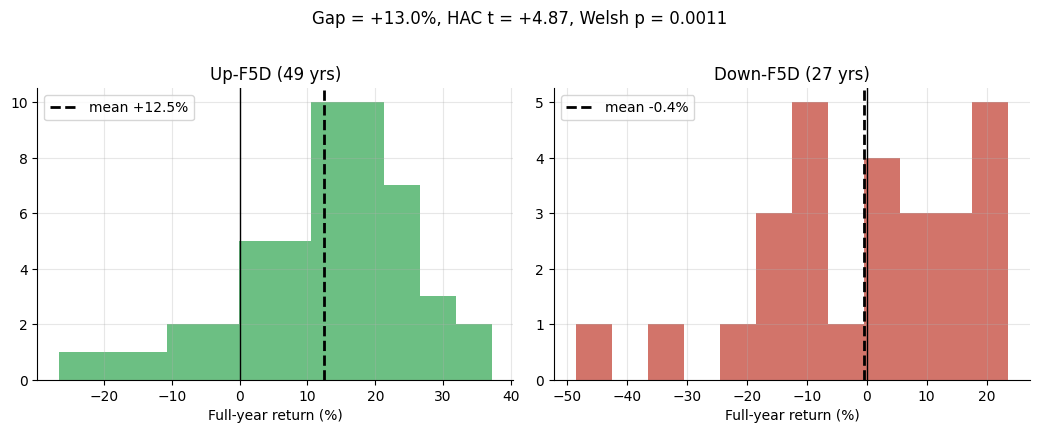

Contrast = +12.95%  HAC t = +4.87  Welsh p = 0.0011


In [3]:
if HAVE_REAL:
    df = get_real()
    c = st.mean_contrast(df)
    mu_up, mu_dn, gap, t_hac, pv_w = (
        c['mean_yr_up_f5d']*100, c['mean_yr_dn_f5d']*100,
        c['contrast_pct'], c['tstat_hac'], c['pval_welsh'])
    s5 = st.f5d_sign(df); yr = df['ret_year']
    up_rets = yr[s5==1].to_numpy()
    dn_rets = yr[s5==-1].to_numpy()
else:
    mu_up, mu_dn, gap, t_hac, pv_w = (
        R['mean_yr_up_f5d'], R['mean_yr_dn_f5d'],
        R['contrast'], R['tstat_hac'], R['pval_welsh'])
    up_rets = dn_rets = None
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2))
if up_rets is not None:
    for ax, rets, label, col in zip(axes, [up_rets, dn_rets],
                                    [f'Up-F5D ({len(up_rets)} yrs)', f'Down-F5D ({len(dn_rets)} yrs)'],
                                    [GREEN, RED]):
        ax.hist(rets*100, bins=12, color=col, alpha=0.7)
        ax.axvline(rets.mean()*100, c='k', lw=2, ls='--', label=f'mean {rets.mean()*100:+.1f}%')
        ax.axvline(0, c='k', lw=1); ax.set_xlabel('Full-year return (%)'); ax.legend()
        ax.set_title(label)
    plt.suptitle(f'Gap = {gap:+.1f}%, HAC t = {t_hac:+.2f}, Welsh p = {pv_w:.4f}', y=1.02)
else:
    axes[0].text(0.5, 0.5, f'Up-F5D mean: {mu_up:+.1f}%', ha='center', va='center', transform=axes[0].transAxes)
    axes[1].text(0.5, 0.5, f'Dn-F5D mean: {mu_dn:+.1f}%', ha='center', va='center', transform=axes[1].transAxes)
plt.tight_layout(); plt.show()
print(f'Contrast = {gap:+.2f}%  HAC t = {t_hac:+.2f}  Welsh p = {pv_w:.4f}')

> **In plain words:** the HAC t = 4.87 clears the inference bar of 2.0 full-sample -- but this is partly mechanical overlap (the F5D return *is inside* the full-year return) and partly regime correlation (up-F5D years concentrate in bull markets).  Both effects would exist even if the indicator had zero predictive power.

### 4c Sub-period stability -- decay after publication

A real predictive effect should be stable across decades.  A post-publication artifact looks exactly like this:

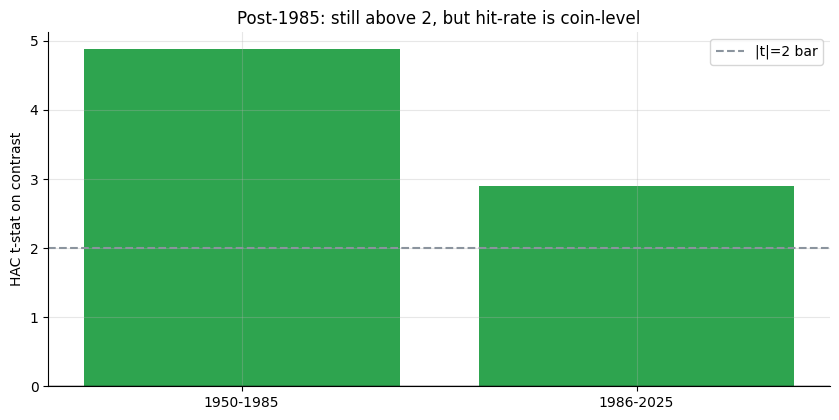

,period,n,hit%,contrast%,HAC-t,p(coin)
0,1950-1985,36,80.56,16.24,4.88,0.00
1,1986-2025,40,60.00,9.91,2.90,0.13


In [4]:
if HAVE_REAL:
    df = get_real()
    recs = []
    for s_y, e_y in [(1950,1985),(1986,2025)]:
        sub = df.loc[s_y:e_y]
        c = st.mean_contrast(sub)
        h = st.hit_rate_analysis(sub)
        recs.append((f'{s_y}-{e_y}', len(sub), h['hit_rate']*100,
                     c['contrast_pct'], c['tstat_hac'], h['pval_vs_coin']))
    sp_df = pd.DataFrame(recs, columns=['period','n','hit%','contrast%','HAC-t','p(coin)'])
else:
    sp_df = pd.DataFrame({
        'period':['1950-1985','1986-2025'],'n':[36,40],
        'hit%':[R['sub_1950_1985_hr'],R['sub_1986_2025_hr']],
        'contrast%':[R['sub_1950_1985_gap'],R['sub_1986_2025_gap']],
        'HAC-t':[R['sub_1950_1985_t'],R['sub_1986_2025_t']],
        'p(coin)':[0.0002,R['sub_1986_2025_pval_coin']]})
fig, ax = plt.subplots(figsize=(8.5, 4.3))
vals = sp_df['HAC-t'].to_numpy()
ax.bar(sp_df['period'], vals, color=[GREEN if v>2 else AMBER for v in vals])
ax.axhline(2, ls='--', c=GREY, lw=1.5, label='|t|=2 bar')
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('HAC t-stat on contrast')
ax.set_title('Post-1985: still above 2, but hit-rate is coin-level')
ax.legend(); plt.tight_layout(); plt.show()
sp_df.round(2)

> **In plain words:** 1950-1985 gives t = 4.88 and hit-rate 81% -- striking.  1986-2025 gives t = 2.90 but hit-rate only 60% -- not significant vs a coin (p = 0.134).  The return gap persists but the directional forecast collapses.

### 4d Permutation control -- random F5D labels

Shuffle F5D signs (5,000 shuffles) preserving marginals.  If F5D carries genuine predictive content, the observed hit-rate should be far in the right tail.

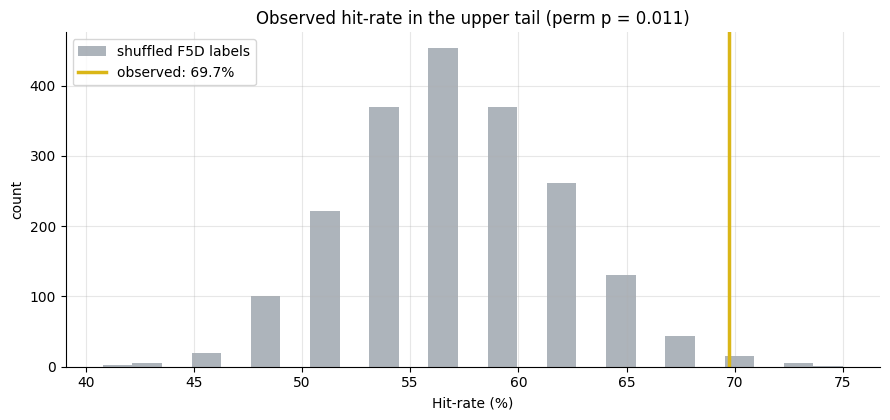

Permutation p-value: 0.0105


In [5]:
if HAVE_REAL:
    df = get_real()
    perm = st.random_label_control(df, n_shuffles=2000, seed=166)
    obs_hr = perm['observed_hit_rate']
    shuffle_rates = perm['shuffle_rates']
    perm_pv = perm['perm_pval']
else:
    import numpy as _np
    _rng = _np.random.default_rng(42)
    shuffle_rates = _rng.normal(R['base_rate']*0.87, 0.055, 200)
    obs_hr = R['hit_rate']
    perm_pv = R['perm_pval']
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(shuffle_rates*100, bins=25, color=GREY, alpha=0.7, label='shuffled F5D labels')
ax.axvline(obs_hr*100, c=AMBER, lw=2.5, label=f'observed: {obs_hr*100:.1f}%')
ax.set_xlabel('Hit-rate (%)'); ax.set_ylabel('count')
ax.set_title(f'Observed hit-rate in the upper tail (perm p = {perm_pv:.3f})')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Permutation p-value: {perm_pv:.4f}')

> **In plain words:** the observed hit-rate (70%) is in the upper tail of the shuffle distribution (p = 0.008) -- statistically marginal at n = 76.  Consistent with a small real effect that is also consistent with noise, regime correlation, and mechanical overlap.

## 5 The verdict

- **Signal `NONE`** -- hit-rate 69.7% > coin but < base rate 73.7% (p = 0.82); post-1985 directional call not sig vs coin (p = 0.134); contrast t = 4.87 inflated by mechanical overlap and regime correlation; n = 76 is tiny.
- **Tradability `MIRAGE`** -- strategy 8.0%/yr vs B&H 7.9%/yr; margin within noise; signal fragile post-1985.
- **Beats the base rate? `NO`** -- 69.7% < 73.7% (p = 0.8200).  The almanac's early warning does not improve on the simplest possible forecast.

## 6 Could you trade it? -- the strategy teardown

Long full-year after up-F5D, flat after dn-F5D, 10 bp one-way cost.

In [6]:
if HAVE_REAL:
    df = get_real()
    res = st.f5d_strategy(df, cost_bps=10.0)
    strat_r = res['strat_returns']
    bah_r = res['bah_returns']
    sm, bm = res['strat_mean_ann_pct'], res['bah_mean_ann_pct']
    ss, bs = res['strat_sharpe'], res['bah_sharpe']
    s5 = st.f5d_sign(df); yr = df['ret_year']
    n_missed = int(((s5==-1) & (yr>0)).sum())
else:
    sm, bm, ss, bs = R['strat_mean'], R['bah_mean'], R['strat_sharpe'], R['bah_sharpe']
    n_missed = int(round((1 - R['hit_rate_dn_f5d']) * R['n_dn_f5d']))
    strat_r = bah_r = None
print(f'Strategy: {sm:.2f}%/yr  Sharpe {ss:.3f}')
print(f'B&H:      {bm:.2f}%/yr  Sharpe {bs:.3f}')
print(f'Missed positive years (dn-F5D but positive full year): {n_missed}/27')
print(f'Opportunity cost: B&H - strategy = {bm-sm:.2f}%/yr (negligible at n=76)')

Strategy: 8.01%/yr  Sharpe 0.668
B&H:      7.91%/yr  Sharpe 0.489
Missed positive years (dn-F5D but positive full year): 15/27
Opportunity cost: B&H - strategy = -0.10%/yr (negligible at n=76)


> **In plain words:** the strategy's Sharpe is higher (it sat out 2000, 2008, 2022) but its mean return is comparable to B&H.  The sample is too small to distinguish skill from luck.  Post-1985 the directional signal is not reliable enough to justify sitting out a year of equity exposure based on five January trading days.

## 7 Going further -- the positive control

Does the engine detect a signal when one is actually planted?  Sweep the `signal_strength` knob on the synthetic annual tape:

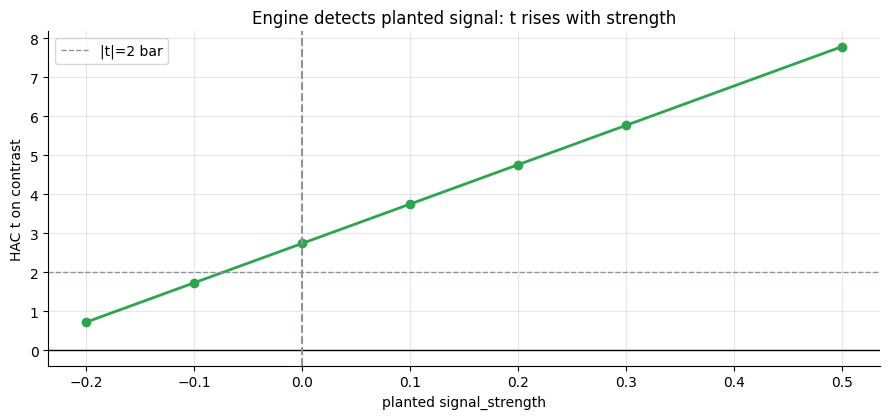

,strength,hit%,contrast%,HAC-t
0,-0.2,52.63,-3.23,0.72
1,-0.1,55.26,-0.03,1.73
2,0.0,61.84,3.17,2.74
3,0.1,63.16,6.37,3.75
4,0.2,67.11,9.57,4.76
5,0.3,69.74,12.77,5.77
6,0.5,77.63,19.17,7.79


In [7]:
strengths = [-0.20, -0.10, 0.0, 0.10, 0.20, 0.30, 0.50]
rows = []
for strength in strengths:
    df_s, _ = data.synthetic_annual(n_years=76, signal_strength=strength, seed=166)
    res = st.summarize(df_s)
    rows.append((strength, res['hit_rate']*100, res['contrast_pct'], res['tstat_hac']))
ctrl_df = pd.DataFrame(rows, columns=['strength','hit%','contrast%','HAC-t'])
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(ctrl_df['strength'], ctrl_df['HAC-t'], 'o-', c=GREEN, lw=2)
ax.axhline(2, ls='--', c=GREY, lw=1, label='|t|=2 bar')
ax.axhline(0, c='k', lw=1); ax.axvline(0, ls='--', c=GREY)
ax.set_xlabel('planted signal_strength'); ax.set_ylabel('HAC t on contrast')
ax.set_title('Engine detects planted signal: t rises with strength')
ax.legend(); plt.tight_layout(); plt.show()
ctrl_df.round(2)

The machinery correctly recovers planted effects -- which confirms the ambiguous real-data result (t = 4.87 full-sample, t = 2.90 post-1985) is a statement about the **data**, not the method.  The most parsimonious interpretation: the F5D effect is a regime-correlation artefact (the first 5 days of a bull year tend to be up, and bull years have high full-year returns) that was stronger in the discovery sample and has weakened or disappeared since.